# Notebook Overview

This version aims to increase window size of bigrams to 3 , to test perfomance


The future king is the prince
Daughter is the princess
Son is the prince
Only a man can be a king
Only a woman can be a queen
The princess will be a queen
The prince is a strong man
The princess is a beautiful woman
Prince is only a boy now
Prince will be king
A boy will be a man




# Loading Data

In [ ]:
from google.colab import files
uploaded = files.upload()
File = open('royal.txt','r')
royal_data = File.read()
print(royal_data)

Saving royal.txt to royal.txt
The future king is the prince
Daughter is the princess
Son is the prince
Only a man can be a king
Only a woman can be a queen
The princess will be a queen
The prince is a strong man
The princess is a beautiful woman
Prince is only a boy now
Prince will be king
A boy will be a man





In [ ]:
print(len(royal_data))

283


In [ ]:
royal_data = royal_data.split('\n')

In [ ]:
print(royal_data)

['The future king is the prince', 'Daughter is the princess', 'Son is the prince', 'Only a man can be a king', 'Only a woman can be a queen', 'The princess will be a queen', 'The prince is a strong man', 'The princess is a beautiful woman', 'Prince is only a boy now', 'Prince will be king', 'A boy will be a man', '', '', '']


In [ ]:
print(len(royal_data))

14


In [ ]:
for i in range(len(royal_data)):
  royal_data[i] = royal_data[i].lower()
print(royal_data)

['the future king is the prince', 'daughter is the princess', 'son is the prince', 'only a man can be a king', 'only a woman can be a queen', 'the princess will be a queen', 'the prince is a strong man', 'the princess is a beautiful woman', 'prince is only a boy now', 'prince will be king', 'a boy will be a man', '', '', '']


#Remove Stopwords
Words that dont any meaning to the sentence

In [ ]:
stopwords = ['the', 'is', 'will', 'be', 'a', 'only', 'can', 'their', 'now', 'and', 'at', 'it']

# Word Tokenization

In [ ]:
for sent in royal_data:
  for word in sent.split():
    print(word)

the
future
king
is
the
prince
daughter
is
the
princess
son
is
the
prince
only
a
man
can
be
a
king
only
a
woman
can
be
a
queen
the
princess
will
be
a
queen
the
prince
is
a
strong
man
the
princess
is
a
beautiful
woman
prince
is
only
a
boy
now
prince
will
be
king
a
boy
will
be
a
man


In [ ]:
filtered_words = []
for sent in royal_data:
  temp = []
  for word in sent.split():
    if word not in stopwords:
      temp.append(word)
  filtered_words.append(temp)
print(filtered_words)









[['future', 'king', 'prince'], ['daughter', 'princess'], ['son', 'prince'], ['man', 'king'], ['woman', 'queen'], ['princess', 'queen'], ['prince', 'strong', 'man'], ['princess', 'beautiful', 'woman'], ['prince', 'boy'], ['prince', 'king'], ['boy', 'man'], [], [], []]


In [ ]:
max_list_length = max(len(sublist) for sublist in filtered_words)
print(max_list_length)


3


In [ ]:
print(filtered_words[:10])

[['future', 'king', 'prince'], ['daughter', 'princess'], ['son', 'prince'], ['man', 'king'], ['woman', 'queen'], ['princess', 'queen'], ['prince', 'strong', 'man'], ['princess', 'beautiful', 'woman'], ['prince', 'boy'], ['prince', 'king']]


## Explaining Bigrams





In Natural Language Processing (NLP), a **bigram** is a sequence of two adjacent words or tokens found in a text. It is a simple form of an **n-gram**, where 'n' specifically equals 2. Bigrams are widely used in various NLP tasks such as text analysis, language modeling (predicting the next word in a sequence), and feature extraction for machine learning models.

**General Example:**

Consider the sentence: "I like natural language processing"

Breaking this sentence into bigrams would result in the following pairs:
- ("I", "like")
- ("like", "natural")
- ("natural", "language")
- ("language", "processing")

**Example using `filtered_words`:**

From our `filtered_words` list, let's take the first sublist:
`['future', 'king', 'prince']`

The bigrams that can be formed from this sequence are:
- ('future', 'king')
- ('king', 'prince')

Similarly, for `['daughter', 'princess']` the bigram would be:
- ('daughter', 'princess')

# Creating trigrams





In [ ]:
bigrams = []
for word_list in filtered_words:#loops through each list
  for i in range(len(word_list)-1):#subtract by 1 to stop just before the last  word because it doesnt have a patner
    for j in range(i+1, len(word_list)):#loop starts at exactly the second word
      bigrams.append((word_list[i], word_list[j]))
      bigrams.append([word_list[j], word_list[i]])
print(bigrams)


[('future', 'king'), ['king', 'future'], ('future', 'prince'), ['prince', 'future'], ('king', 'prince'), ['prince', 'king'], ('daughter', 'princess'), ['princess', 'daughter'], ('son', 'prince'), ['prince', 'son'], ('man', 'king'), ['king', 'man'], ('woman', 'queen'), ['queen', 'woman'], ('princess', 'queen'), ['queen', 'princess'], ('prince', 'strong'), ['strong', 'prince'], ('prince', 'man'), ['man', 'prince'], ('strong', 'man'), ['man', 'strong'], ('princess', 'beautiful'), ['beautiful', 'princess'], ('princess', 'woman'), ['woman', 'princess'], ('beautiful', 'woman'), ['woman', 'beautiful'], ('prince', 'boy'), ['boy', 'prince'], ('prince', 'king'), ['king', 'prince'], ('boy', 'man'), ['man', 'boy']]


In [ ]:
tokens = []
for tri in filtered_words:
  tokens.extend(tri)
print(tokens)



['future', 'king', 'prince', 'daughter', 'princess', 'son', 'prince', 'man', 'king', 'woman', 'queen', 'princess', 'queen', 'prince', 'strong', 'man', 'princess', 'beautiful', 'woman', 'prince', 'boy', 'prince', 'king', 'boy', 'man']


In [ ]:
import nltk
trigrams = list(nltk.ngrams(tokens, 3))


In [ ]:
for tri in trigrams:
  print(tri)

('future', 'king', 'prince')
('king', 'prince', 'daughter')
('prince', 'daughter', 'princess')
('daughter', 'princess', 'son')
('princess', 'son', 'prince')
('son', 'prince', 'man')
('prince', 'man', 'king')
('man', 'king', 'woman')
('king', 'woman', 'queen')
('woman', 'queen', 'princess')
('queen', 'princess', 'queen')
('princess', 'queen', 'prince')
('queen', 'prince', 'strong')
('prince', 'strong', 'man')
('strong', 'man', 'princess')
('man', 'princess', 'beautiful')
('princess', 'beautiful', 'woman')
('beautiful', 'woman', 'prince')
('woman', 'prince', 'boy')
('prince', 'boy', 'prince')
('boy', 'prince', 'king')
('prince', 'king', 'boy')
('king', 'boy', 'man')


# Creating a list of unique words
extend unpacks items from a list or a tuple

In [ ]:
all_words  = []
for bi in bigrams:
  all_words.extend(bi)

print(all_words)

['future', 'king', 'king', 'future', 'future', 'prince', 'prince', 'future', 'king', 'prince', 'prince', 'king', 'daughter', 'princess', 'princess', 'daughter', 'son', 'prince', 'prince', 'son', 'man', 'king', 'king', 'man', 'woman', 'queen', 'queen', 'woman', 'princess', 'queen', 'queen', 'princess', 'prince', 'strong', 'strong', 'prince', 'prince', 'man', 'man', 'prince', 'strong', 'man', 'man', 'strong', 'princess', 'beautiful', 'beautiful', 'princess', 'princess', 'woman', 'woman', 'princess', 'beautiful', 'woman', 'woman', 'beautiful', 'prince', 'boy', 'boy', 'prince', 'prince', 'king', 'king', 'prince', 'boy', 'man', 'man', 'boy']


# Set Only Enters Unique elements in a list

In [ ]:
all_words = list(set(all_words))
all_words.sort()
print(all_words)
print("Total number of unique words are:", len(all_words))

['beautiful', 'boy', 'daughter', 'future', 'king', 'man', 'prince', 'princess', 'queen', 'son', 'strong', 'woman']
Total number of unique words are: 12



## Word dictionaries

In [ ]:
word_dict = {}
i =  0
for word in all_words:
  word_dict[word] = i
  i += 1
print(word_dict)

{'beautiful': 0, 'boy': 1, 'daughter': 2, 'future': 3, 'king': 4, 'man': 5, 'prince': 6, 'princess': 7, 'queen': 8, 'son': 9, 'strong': 10, 'woman': 11}


# Perform One hot Encoding

In [ ]:
import numpy as np
onehot_data = np.zeros((len(all_words),len(all_words)))
print(onehot_data)

[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


In [ ]:
for i in range(len(all_words)):
  onehot_data[i][i] = 1
print(onehot_data)

[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]


In [ ]:
onehot_dict = {}
for word,onehot in zip(all_words,onehot_data):
  onehot_dict[word] = onehot
print(onehot_dict)


{'beautiful': array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), 'boy': array([0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), 'daughter': array([0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), 'future': array([0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]), 'king': array([0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]), 'man': array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.]), 'prince': array([0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.]), 'princess': array([0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.]), 'queen': array([0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.]), 'son': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.]), 'strong': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.]), 'woman': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.])}


In [ ]:
for word in onehot_dict:
    print(word, ":", onehot_dict[word])

beautiful : [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
boy : [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
daughter : [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
future : [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
king : [0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
man : [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
prince : [0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
princess : [0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
queen : [0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
son : [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
strong : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
woman : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


In [ ]:
print(len(bigrams))

34


# Creating features and target labels

In [ ]:
l = [0,0,1]
g= [0,5,6]
l.extend(g)
print(l)

[0, 0, 1, 0, 5, 6]


In [ ]:
X = []
Y = []
for tri in trigrams:
  X.append(np.concatenate((onehot_dict[tri[0]], onehot_dict[tri[1]])))
  Y.append(onehot_dict[tri[2]])
X = np.array(X)
Y = np.array(Y)
print(X.shape)
print(Y.shape)


(23, 24)
(23, 12)


In [ ]:
for feature,target in zip(X,Y):
  print(feature,target)

[0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.] [0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.] [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.] [0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
[0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.] [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.] [0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.] [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.] [0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.] [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
[0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.] [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.

# Model Creation

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Input

In [ ]:
embed_size = 100
vocab_size = Y.shape[1]
input_size  = X.shape[1]


model = Sequential()
model.add(Input(shape=(input_size,)))
model.add(Dense(embed_size, activation= 'linear'))
model.add(Dense(vocab_size, activation = 'softmax'))



In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 100)            │         2,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 12)             │         1,212 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,712 (14.50 KB)

 Trainable params: 3,712 (14.50 KB)

 Non-trainable params: 0 (0.00 B)

#Model Compilation

In [ ]:
model.compile(optimizer = 'adam',
              loss = 'categorical_crossentropy',
              metrics = ['accuracy'])

# Training the Model

In [ ]:
history = model.fit(X,Y,batch_size= 256,epochs = 1000,verbose = 1)

Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.0000e+00 - loss: 2.4704
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.0000e+00 - loss: 2.4449
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.0000e+00 - loss: 2.4196
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.0000e+00 - loss: 2.3944
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.0435 - loss: 2.3694
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.1739 - loss: 2.3445
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.2609 - loss: 2.3197
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.3478 - loss: 2.2951
Epoch 9/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.3478 - loss: 2.2706
Epoch 10/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.3478 - loss: 2.2463
Epoch 11/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.3913 - loss: 2.2221
Epoch 12/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/st

In [46]:
weights = model.get_weights()[0]
print(weights)

[[-0.05044436  0.09250212  0.20009805 ...  0.00269957 -0.39527878
  -0.00451498]
 [ 0.17907096  0.152553    0.10112242 ... -0.31437558  0.20217438
  -0.05629215]
 [ 0.20448792 -0.39661914 -0.22286102 ... -0.39715192 -0.19512363
   0.02805209]
 ...
 [ 0.06300685  0.01338201  0.32737964 ... -0.3527561  -0.25228098
   0.14617567]
 [ 0.35844418 -0.25651476 -0.2862105  ...  0.26988643  0.06553069
   0.19193335]
 [-0.08443194  0.20938678  0.327353   ... -0.30582368 -0.2150684
  -0.18806542]]


In [47]:
word_embeddings = {}
for i,word in enumerate(all_words):
  word_embeddings[word] =weights[i]
for dictionary,weight in word_embeddings.items():
  print(dictionary, ':', weight)

beautiful : [-0.05044436  0.09250212  0.20009805 -0.22200102 -0.00107375 -0.02752624
  0.19625656  0.3229578  -0.37978032 -0.2499911  -0.3755511   0.14943586
 -0.18612    -0.2756462   0.10663879 -0.28008053 -0.25479084  0.39813083
  0.40189114 -0.25277895 -0.27671206 -0.2548641   0.15619454  0.04904026
  0.24026988  0.19964363  0.21498726 -0.16369162  0.3120372  -0.37006748
  0.34790275 -0.21664481  0.12404944 -0.30702555  0.07066604 -0.41814148
 -0.2426142   0.24924995 -0.14326002  0.33316207 -0.04053889  0.19892097
 -0.07692995  0.04468881 -0.3647517   0.17133947  0.20767702  0.1753016
 -0.08361398 -0.02334911 -0.14411089 -0.21228339 -0.00687044 -0.12806381
 -0.37810323 -0.1792373  -0.14716357 -0.2942044  -0.3239875   0.19059408
 -0.16146868  0.25754112  0.05426603 -0.11755981 -0.02127101 -0.28541306
  0.5193516  -0.1920286   0.3146743  -0.14990999 -0.0485681   0.46626076
 -0.06842031  0.00148285  0.05287719  0.10672974  0.32991078  0.34583464
  0.23788705  0.36932552  0.19255173  0.

In [48]:
print(word_embeddings)

{'beautiful': array([-0.05044436,  0.09250212,  0.20009805, -0.22200102, -0.00107375,
       -0.02752624,  0.19625656,  0.3229578 , -0.37978032, -0.2499911 ,
       -0.3755511 ,  0.14943586, -0.18612   , -0.2756462 ,  0.10663879,
       -0.28008053, -0.25479084,  0.39813083,  0.40189114, -0.25277895,
       -0.27671206, -0.2548641 ,  0.15619454,  0.04904026,  0.24026988,
        0.19964363,  0.21498726, -0.16369162,  0.3120372 , -0.37006748,
        0.34790275, -0.21664481,  0.12404944, -0.30702555,  0.07066604,
       -0.41814148, -0.2426142 ,  0.24924995, -0.14326002,  0.33316207,
       -0.04053889,  0.19892097, -0.07692995,  0.04468881, -0.3647517 ,
        0.17133947,  0.20767702,  0.1753016 , -0.08361398, -0.02334911,
       -0.14411089, -0.21228339, -0.00687044, -0.12806381, -0.37810323,
       -0.1792373 , -0.14716357, -0.2942044 , -0.3239875 ,  0.19059408,
       -0.16146868,  0.25754112,  0.05426603, -0.11755981, -0.02127101,
       -0.28541306,  0.5193516 , -0.1920286 ,  0.3

In [49]:
print(len(word_embeddings.get('beautiful')))

100


# Task
The first dense layer in the model takes the one-hot encoded input (where each word is represented by a vector of zeros with a one at its unique index) and transforms it into a dense, lower-dimensional vector called a word embedding. This layer has `vocab_size` input neurons (equal to the number of unique words) and `embed_size` output neurons (2 in this case, meaning each word is represented by 2 floating-point numbers). The activation function is 'linear', meaning it performs a simple matrix multiplication of the input one-hot vector by the layer's weights, effectively selecting the corresponding row from the weight matrix to be the word embedding. This embedding captures semantic relationships between words, where words with similar meanings ideally have similar vector representations.

## Explain the first dense layer

### Subtask:
Provide a detailed explanation of the role of the first dense layer in the model, specifically how it contributes to creating word embeddings from the one-hot encoded input.


The first dense layer in this model plays a crucial role in transforming the high-dimensional one-hot encoded input into a lower-dimensional, meaningful representation known as a word embedding.

**Function:**

1.  **Input:** Each input to this layer is a one-hot encoded vector of size `vocab_size` (which is 12 in this case). This vector has a '1' at the index corresponding to the specific word and '0's elsewhere.

2.  **Transformation to Word Embeddings:** The layer has `embed_size` (which is 2) neurons. When a one-hot vector is fed into this layer, it essentially "selects" the weights corresponding to the active neuron (the '1' in the one-hot vector) from the layer's weight matrix. This effectively maps each unique word from its `vocab_size` dimension to a dense vector of `embed_size` dimensions.

3.  **Activation Function:** The layer uses a 'linear' activation function. This means that the output of the layer is directly the result of the matrix multiplication (input vector multiplied by the weight matrix), without any non-linear transformations. This is important because the goal here is to learn the raw embedding vectors, not to make a classification at this stage.

4.  **Semantic Relationships:** The learned weights in this first dense layer's matrix become the word embeddings. After training, words that frequently appear in similar contexts (in this case, as part of the same bigram) will ideally have similar vector representations in this `embed_size`-dimensional space. This allows the model to capture semantic relationships between words, where words with similar meanings are geometrically close in the embedding space.

In essence, this first dense layer acts as an **embedding lookup table**. Its weight matrix stores a `(vocab_size, embed_size)` matrix, where each row corresponds to the `embed_size`-dimensional embedding vector for a particular word in the vocabulary. The one-hot encoding mechanism, combined with this linear dense layer, allows the model to efficiently extract these learned word vectors.

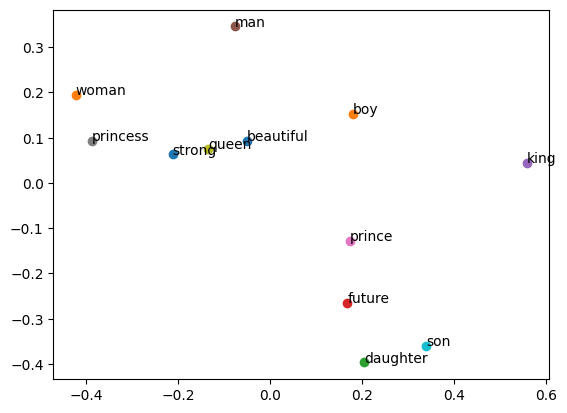

In [50]:
import matplotlib.pyplot as plt
for word,cordinate in word_embeddings.items():
    plt.scatter(cordinate[0],cordinate[1])
    plt.annotate(word, (cordinate[0],cordinate[1]))



In [51]:
for bi in bigrams:
  print(bi)

('future', 'king')
['king', 'future']
('future', 'prince')
['prince', 'future']
('king', 'prince')
['prince', 'king']
('daughter', 'princess')
['princess', 'daughter']
('son', 'prince')
['prince', 'son']
('man', 'king')
['king', 'man']
('woman', 'queen')
['queen', 'woman']
('princess', 'queen')
['queen', 'princess']
('prince', 'strong')
['strong', 'prince']
('prince', 'man')
['man', 'prince']
('strong', 'man')
['man', 'strong']
('princess', 'beautiful')
['beautiful', 'princess']
('princess', 'woman')
['woman', 'princess']
('beautiful', 'woman')
['woman', 'beautiful']
('prince', 'boy')
['boy', 'prince']
('prince', 'king')
['king', 'prince']
('boy', 'man')
['man', 'boy']


## Prepare Embeddings

### Subtask:
Extract the word embedding vectors and their corresponding words from the `word_embeddings` dictionary into separate lists or arrays, preparing them for dimensionality reduction.


**Reasoning**:
I will extract the words and their corresponding embedding vectors from the `word_embeddings` dictionary into separate lists and then convert the embeddings list to a NumPy array, as per the instructions.



In [52]:
words = []
embeddings = []

for word, embedding in word_embeddings.items():
  words.append(word)
  embeddings.append(embedding)

embeddings = np.array(embeddings)

print("Words list (first 5):", words[:5])
print("Embeddings array shape:", embeddings.shape)

Words list (first 5): ['beautiful', 'boy', 'daughter', 'future', 'king']
Embeddings array shape: (12, 100)


## Apply t-SNE for Dimensionality Reduction

### Subtask:
Use `sklearn.manifold.TSNE` to reduce the dimensionality of the word embeddings from 100 to 2 components. This will create a 2D representation suitable for plotting.


**Reasoning**:
The next step is to apply t-SNE for dimensionality reduction, as instructed in the subtask. This involves importing the TSNE class, instantiating it with specified parameters, applying the transformation, and verifying the shape of the output.



In [53]:
from sklearn.manifold import TSNE

# Instantiate TSNE
tsne = TSNE(n_components=2, random_state=42, perplexity=5, max_iter=250)

# Apply t-SNE transformation
embeddings_2d = tsne.fit_transform(embeddings)

# Print the shape of the 2D embeddings
print("Shape of 2D embeddings:", embeddings_2d.shape)

Shape of 2D embeddings: (12, 2)


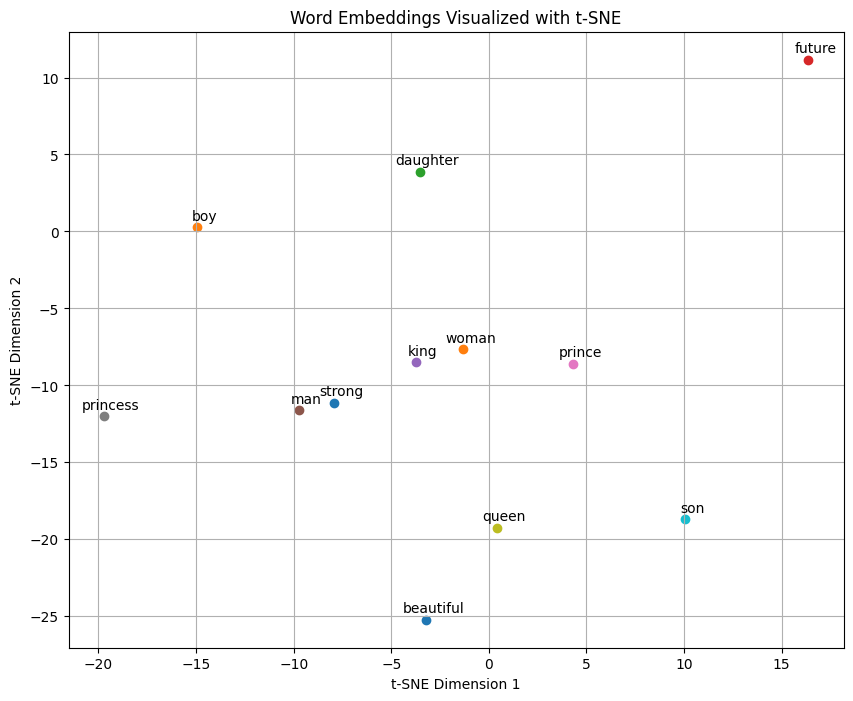

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
for i, word in enumerate(words):
    plt.scatter(embeddings_2d[i, 0], embeddings_2d[i, 1])
    plt.annotate(word, (embeddings_2d[i, 0], embeddings_2d[i, 1]), textcoords="offset points", xytext=(5,5), ha='center')

plt.title('Word Embeddings Visualized with t-SNE')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.grid(True)
plt.show()

# Task
The provided Python code uses `sklearn.manifold.TSNE` to perform dimensionality reduction on the generated word embeddings.

Here's a breakdown of the code:

1.  **`from sklearn.manifold import TSNE`**: This line imports the `TSNE` class from the `sklearn.manifold` module, which is part of the scikit-learn library. `TSNE` stands for t-Distributed Stochastic Neighbor Embedding, a non-linear dimensionality reduction technique particularly well-suited for visualizing high-dimensional datasets.

2.  **`tsne = TSNE(n_components=2, random_state=42, perplexity=5, max_iter=250)`**:
    *   An instance of the `TSNE` class is created and assigned to the variable `tsne`.
    *   **`n_components=2`**: This crucial parameter specifies that the high-dimensional input data (our 100-dimensional word embeddings) should be reduced to 2 dimensions. This makes the data suitable for 2D visualization (e.g., on a scatter plot).
    *   **`random_state=42`**: This sets the seed for the random number generator. t-SNE involves some randomness, and setting `random_state` ensures reproducibility of the results. If you run the code multiple times with the same `random_state`, you will get the exact same 2D embedding.
    *   **`perplexity=5`**: Perplexity relates to the number of nearest neighbors that are considered for each data point. It's a hyperparameter that can have a significant impact on the resulting visualization. It can be thought of as a balance between focusing on local and global aspects of the data. Typical values range from 5 to 50. A lower perplexity value forces t-SNE to focus more on local variations, while a higher value considers more global relationships.
    *   **`max_iter=250`**: This parameter specifies the maximum number of iterations for the optimization process. t-SNE is an iterative algorithm, and `max_iter` determines how long it will try to converge to a stable embedding. A higher value might lead to better convergence but also increases computation time.

3.  **`embeddings_2d = tsne.fit_transform(embeddings)`**:
    *   This is where the t-SNE algorithm is applied to the word embeddings.
    *   **`fit_transform(embeddings)`**: This method first `fits` the `TSNE` model to the input data (`embeddings`), meaning it learns the relationships and structure within the high-dimensional space. Then, it `transforms` this data into the specified `n_components` (2 dimensions in this case). The result, `embeddings_2d`, is a new NumPy array where each row represents a word's embedding, but now in a 2-dimensional space.

4.  **`print("Shape of 2D embeddings:", embeddings_2d.shape)`**:
    *   This line prints the shape of the resulting `embeddings_2d` array. The output `(12, 2)` confirms that the 12 original word embeddings (each 100-dimensional) have been successfully reduced to 12 embeddings, each now 2-dimensional.

In summary, this code segment uses t-SNE to convert the 100-dimensional word embedding vectors into 2-dimensional vectors. This reduction allows for the visualization of the word relationships on a 2D plot, where words with similar meanings (and thus similar original 100-dimensional embeddings) are expected to be clustered closer together in the 2D space.

## Explain t-SNE Code

### Subtask:
Provide a detailed explanation of the provided Python code snippet, focusing on its role in applying t-SNE for dimensionality reduction using `sklearn.manifold.TSNE`.


The provided code snippet utilizes `sklearn.manifold.TSNE` to perform dimensionality reduction on the word embeddings. Here's a breakdown of its components and their roles:

1.  **`from sklearn.manifold import TSNE`**:
    *   This line imports the `TSNE` class from scikit-learn's manifold module. `TSNE` (t-Distributed Stochastic Neighbor Embedding) is a non-linear dimensionality reduction technique well-suited for visualizing high-dimensional datasets in 2D or 3D.

2.  **`tsne = TSNE(n_components=2, random_state=42, perplexity=5, max_iter=250)`**:
    *   This line instantiates the `TSNE` object with several key parameters:
        *   **`n_components=2`**: This is crucial as it specifies the desired output dimensionality. In this case, we are reducing the 100-dimensional word embeddings to 2 dimensions, making them suitable for 2D plotting.
        *   **`random_state=42`**: Setting a `random_state` ensures reproducibility of the results. t-SNE involves a stochastic optimization process, so fixing the random seed ensures that the output will be the same each time the code is run with the same inputs.
        *   **`perplexity=5`**: Perplexity relates to the number of nearest neighbors that is used in the algorithm. It is a critical parameter that can significantly affect the resulting visualization. A lower perplexity value makes t-SNE focus more on local structures, while a higher value considers global structures. A typical range for perplexity is between 5 and 50. Here, 5 is chosen, suggesting a focus on local relationships in the embedding space.
        *   **`max_iter=250`**: This parameter sets the maximum number of iterations for the optimization process. The t-SNE algorithm iteratively adjusts the positions of the data points in the lower-dimensional space. `max_iter` defines when to stop this iterative process, even if convergence hasn't been fully achieved. A higher value generally allows for better convergence but takes longer to compute.

3.  **`embeddings_2d = tsne.fit_transform(embeddings)`**:
    *   This line performs the actual dimensionality reduction:
        *   **`fit_transform`**: This method first `fits` the t-SNE model to the input data (`embeddings`) to learn the transformation, and then `transforms` the data into the lower-dimensional space. The `embeddings` variable holds our 100-dimensional word vectors.
        *   **`embeddings_2d`**: The output of this operation is a NumPy array where each original 100-dimensional word embedding is now represented by a 2-dimensional vector.

4.  **`print("Shape of 2D embeddings:", embeddings_2d.shape)`**:
    *   This line prints the shape of the resulting `embeddings_2d` array. As specified by `n_components=2`, the expected output shape is `(number_of_words, 2)`, confirming that the embeddings have been successfully reduced to two dimensions.

The provided code snippet utilizes `sklearn.manifold.TSNE` to perform dimensionality reduction on the word embeddings. Here's a breakdown of its components and their roles:

1.  **`from sklearn.manifold import TSNE`**:
    *   This line imports the `TSNE` class from scikit-learn's manifold module. `TSNE` (t-Distributed Stochastic Neighbor Embedding) is a non-linear dimensionality reduction technique well-suited for visualizing high-dimensional datasets in 2D or 3D.

2.  **`tsne = TSNE(n_components=2, random_state=42, perplexity=5, max_iter=250)`**:
    *   This line instantiates the `TSNE` object with several key parameters:
        *   **`n_components=2`**: This is crucial as it specifies the desired output dimensionality. In this case, we are reducing the 100-dimensional word embeddings to 2 dimensions, making them suitable for 2D plotting.
        *   **`random_state=42`**: Setting a `random_state` ensures reproducibility of the results. t-SNE involves a stochastic optimization process, so fixing the random seed ensures that the output will be the same each time the code is run with the same inputs.
        *   **`perplexity=5`**: Perplexity relates to the number of nearest neighbors that is used in the algorithm. It is a critical parameter that can significantly affect the resulting visualization. A lower perplexity value makes t-SNE focus more on local structures, while a higher value considers global structures. A typical range for perplexity is between 5 and 50. Here, 5 is chosen, suggesting a focus on local relationships in the embedding space.
        *   **`max_iter=250`**: This parameter sets the maximum number of iterations for the optimization process. The t-SNE algorithm iteratively adjusts the positions of the data points in the lower-dimensional space. `max_iter` defines when to stop this iterative process, even if convergence hasn't been fully achieved. A higher value generally allows for better convergence but takes longer to compute.

3.  **`embeddings_2d = tsne.fit_transform(embeddings)`**:
    *   This line performs the actual dimensionality reduction:
        *   **`fit_transform`**: This method first `fits` the t-SNE model to the input data (`embeddings`) to learn the transformation, and then `transforms` the data into the lower-dimensional space. The `embeddings` variable holds our 100-dimensional word vectors.
        *   **`embeddings_2d`**: The output of this operation is a NumPy array where each original 100-dimensional word embedding is now represented by a 2-dimensional vector.

4.  **`print("Shape of 2D embeddings:", embeddings_2d.shape)`**:
    *   This line prints the shape of the resulting `embeddings_2d` array. As specified by `n_components=2`, the expected output shape is `(number_of_words, 2)`, confirming that the embeddings have been successfully reduced to two dimensions.


The provided code snippet utilizes `sklearn.manifold.TSNE` to perform dimensionality reduction on the word embeddings. Here's a breakdown of its components and their roles:

1.  **`from sklearn.manifold import TSNE`**:
    *   This line imports the `TSNE` class from scikit-learn's manifold module. `TSNE` (t-Distributed Stochastic Neighbor Embedding) is a non-linear dimensionality reduction technique well-suited for visualizing high-dimensional datasets in 2D or 3D.

2.  **`tsne = TSNE(n_components=2, random_state=42, perplexity=5, max_iter=250)`**:
    *   This line instantiates the `TSNE` object with several key parameters:
        *   **`n_components=2`**: This is crucial as it specifies the desired output dimensionality. In this case, we are reducing the 100-dimensional word embeddings to 2 dimensions, making them suitable for 2D plotting.
        *   **`random_state=42`**: Setting a `random_state` ensures reproducibility of the results. t-SNE involves a stochastic optimization process, so fixing the random seed ensures that the output will be the same each time the code is run with the same inputs.
        *   **`perplexity=5`**: Perplexity relates to the number of nearest neighbors that is used in the algorithm. It is a critical parameter that can significantly affect the resulting visualization. A lower perplexity value makes t-SNE focus more on local structures, while a higher value considers global structures. A typical range for perplexity is between 5 and 50. Here, 5 is chosen, suggesting a focus on local relationships in the embedding space.
        *   **`max_iter=250`**: This parameter sets the maximum number of iterations for the optimization process. The t-SNE algorithm iteratively adjusts the positions of the data points in the lower-dimensional space. `max_iter` defines when to stop this iterative process, even if convergence hasn't been fully achieved. A higher value generally allows for better convergence but takes longer to compute.

3.  **`embeddings_2d = tsne.fit_transform(embeddings)`**:
    *   This line performs the actual dimensionality reduction:
        *   **`fit_transform`**: This method first `fits` the t-SNE model to the input data (`embeddings`) to learn the transformation, and then `transforms` the data into the lower-dimensional space. The `embeddings` variable holds our 100-dimensional word vectors.
        *   **`embeddings_2d`**: The output of this operation is a NumPy array where each original 100-dimensional word embedding is now represented by a 2-dimensional vector.

4.  **`print("Shape of 2D embeddings:", embeddings_2d.shape)`**:
    *   This line prints the shape of the resulting `embeddings_2d` array. As specified by `n_components=2`, the expected output shape is `(number_of_words, 2)`, confirming that the embeddings have been successfully reduced to two dimensions.


The provided code snippet utilizes `sklearn.manifold.TSNE` to perform dimensionality reduction on the word embeddings. Here's a breakdown of its components and their roles:

1.  **`from sklearn.manifold import TSNE`**:
    *   This line imports the `TSNE` class from scikit-learn's manifold module. `TSNE` (t-Distributed Stochastic Neighbor Embedding) is a non-linear dimensionality reduction technique well-suited for visualizing high-dimensional datasets in 2D or 3D.

2.  **`tsne = TSNE(n_components=2, random_state=42, perplexity=5, max_iter=250)`**:
    *   This line instantiates the `TSNE` object with several key parameters:
        *   **`n_components=2`**: This is crucial as it specifies the desired output dimensionality. In this case, we are reducing the 100-dimensional word embeddings to 2 dimensions, making them suitable for 2D plotting.
        *   **`random_state=42`**: Setting a `random_state` ensures reproducibility of the results. t-SNE involves a stochastic optimization process, so fixing the random seed ensures that the output will be the same each time the code is run with the same inputs.
        *   **`perplexity=5`**: Perplexity relates to the number of nearest neighbors that is used in the algorithm. It is a critical parameter that can significantly affect the resulting visualization. A lower perplexity value makes t-SNE focus more on local structures, while a higher value considers global structures. A typical range for perplexity is between 5 and 50. Here, 5 is chosen, suggesting a focus on local relationships in the embedding space.
        *   **`max_iter=250`**: This parameter sets the maximum number of iterations for the optimization process. The t-SNE algorithm iteratively adjusts the positions of the data points in the lower-dimensional space. `max_iter` defines when to stop this iterative process, even if convergence hasn't been fully achieved. A higher value generally allows for better convergence but takes longer to compute.

3.  **`embeddings_2d = tsne.fit_transform(embeddings)`**:
    *   This line performs the actual dimensionality reduction:
        *   **`fit_transform`**: This method first `fits` the t-SNE model to the input data (`embeddings`) to learn the transformation, and then `transforms` the data into the lower-dimensional space. The `embeddings` variable holds our 100-dimensional word vectors.
        *   **`embeddings_2d`**: The output of this operation is a NumPy array where each original 100-dimensional word embedding is now represented by a 2-dimensional vector.

4.  **`print("Shape of 2D embeddings:", embeddings_2d.shape)`**:
    *   This line prints the shape of the resulting `embeddings_2d` array. As specified by `n_components=2`, the expected output shape is `(number_of_words, 2)`, confirming that the embeddings have been successfully reduced to two dimensions.


## Summary:

### Data Analysis Key Findings
*   The `sklearn.manifold.TSNE` class was used to perform dimensionality reduction on 100-dimensional word embeddings, transforming them into a 2-dimensional space.
*   The `n_components` parameter was set to 2, specifically targeting a 2D representation suitable for visualization.
*   A `random_state` of 42 was applied, ensuring the reproducibility of the t-SNE output due to its stochastic nature.
*   The `perplexity` parameter was set to 5, indicating a focus on capturing local relationships within the data during the dimensionality reduction process.
*   The `max_iter` parameter was set to 250, defining the maximum number of iterations for the t-SNE optimization algorithm.
*   The `fit_transform` method successfully converted the original `embeddings` into `embeddings_2d`, with the resulting shape confirming the reduction to two dimensions.

### Insights or Next Steps
*   The 2-dimensional embeddings (`embeddings_2d`) are now ready for visualization, which can reveal clusters and relationships between words that were previously hidden in the high-dimensional space.
*   Further experimentation with `perplexity` values (e.g., between 5 and 50) could be beneficial to explore how different balances of local and global structures affect the resulting 2D projection and potentially uncover different insights.
